# 1-Photon Calcium Imaging Binarization Pipeline

Demonstrates binarizing one-photon (Inscopix / fibre photometry) calcium data
using `binarize2pcalcium`.  Uses the built-in simulation module with realistic
GCaMP kinetics configured for noisier 1P recordings.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from binarize2pcalcium import binarize, BinarizationResult
from binarize2pcalcium.data_simulation import SimulationConfig, simulate_calcium_data

print("Setup complete.")

Setup complete.


## 1. Simulate realistic 1P data

`SimulationConfig.for_1p()`: 20 Hz, slower GCaMP, lower photon counts, stronger transients.

In [2]:
cfg = SimulationConfig.for_1p(amplitude_mean=0.50, event_rate=0.04)
F_noisy, dff_true = simulate_calcium_data(cfg)
print(f"F shape: {F_noisy.shape}")

F shape: (25, 6000)


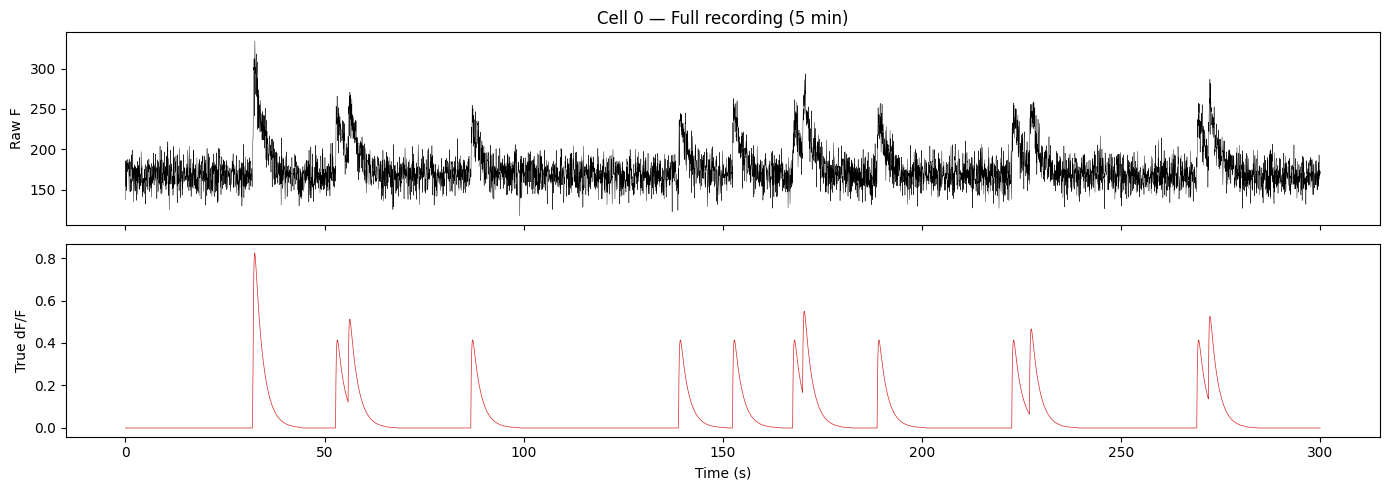

In [3]:
cell_id = 0
t = np.arange(cfg.n_timepoints) / cfg.sample_rate
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
ax1.plot(t, F_noisy[cell_id], linewidth=0.3, color='k')
ax1.set_ylabel('Raw F'); ax1.set_title(f'Cell {cell_id} — Full recording (5 min)')
ax2.plot(t, dff_true[cell_id], linewidth=0.5, color='C3')
ax2.set_ylabel('True dF/F'); ax2.set_xlabel('Time (s)')
plt.tight_layout(); plt.show()

## 2. Binarize with source-default 1P parameters

All values match `Calcium.set_default_parameters_1p()` exactly.

In [4]:
result = binarize(
    F_noisy,
    sample_rate=20,
    data_type='1p',
    high_cutoff=1.0,                # source default
    percentile_threshold=0.99999,   # source default
    dff_min=0.10,                   # source default
    min_width_onphase=20,           # source default (= sample_rate)
    min_width_upphase=6,            # source default (= sample_rate // 3)
    remove_ends=False,              # source default
    maximum_std_of_signal=0.03,     # source default (1P)
    moment_flag=True,               # source default (1P)
    moment=2, moment_threshold=0.01, moment_scaling=0.5,
    verbose=True,
)

cells_on = (result.onphase.sum(axis=1) > 0).sum()
cells_up = (result.upphase.sum(axis=1) > 0).sum()
print(f"Onphase events: {result.onphase.sum():,}  ({cells_on} / {result.onphase.shape[0]} cells)")
print(f"Upphase events: {result.upphase.sum():,}  ({cells_up} / {result.upphase.shape[0]} cells)")

Running binarization pipeline:
  data_type=1p, sample_rate=20 Hz
  high_cutoff=1.0 Hz, detrend_order=1
  Input shape: (25, 6000)


model filter: remove bleaching or trends: 100%|██████████| 25/25 [00:00<00:00, 903.79it/s]

  Computing thresholds...



c:\Users\mauls\Documents\Code\binarize2pcalcium\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 25/25 [00:02<00:00, 10.34it/s]


  Adjusting thresholds via moment analysis...
  Binarizing onphase...


binarizing continuous tracesfiltered fluorescence onphase: 100%|██████████| 25/25 [00:00<00:00, 2111.60it/s]


  Binarizing upphase...


binarizing continuous traces filtered fluorescence upphase: 100%|██████████| 25/25 [00:00<00:00, 893.34it/s]

  Done. Onphase events: 63836, Upphase events: 19688
Onphase events: 63,836.0  (25 / 25 cells)
Upphase events: 19,688.0  (25 / 25 cells)


## 3. Full 5-minute overview

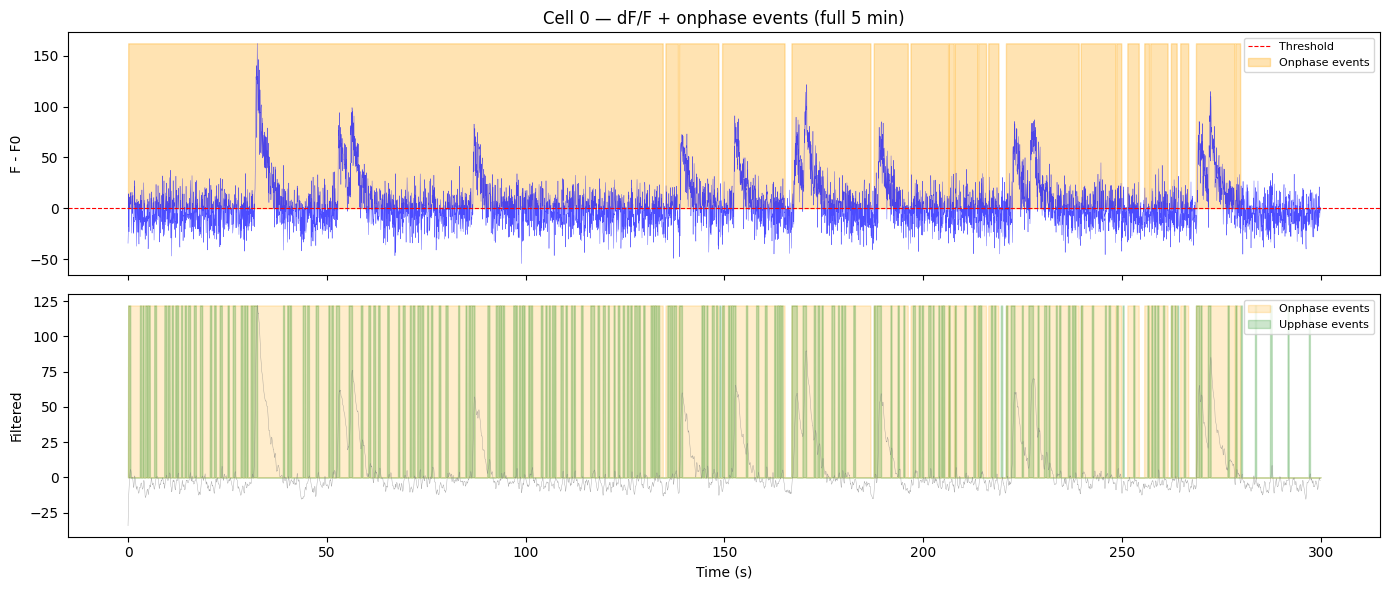

In [5]:
cell_id = 0
t = np.arange(result.F_raw.shape[1]) / cfg.sample_rate

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(t, result.dff[cell_id], 'b', linewidth=0.3, alpha=0.7)
ax1.axhline(y=result.thresholds[cell_id], color='r', linestyle='--', linewidth=0.8, label='Threshold')
ymax = result.dff[cell_id].max()
ax1.fill_between(t, 0, result.onphase[cell_id] * ymax,
                 alpha=0.3, color='orange', label='Onphase events')
ax1.set_ylabel('F - F0'); ax1.set_title(f'Cell {cell_id} — dF/F + onphase events (full 5 min)')
ax1.legend(fontsize=8, loc='upper right')

ax2.plot(t, result.F_filtered[cell_id], 'gray', linewidth=0.3, alpha=0.7)
ymax = result.F_filtered[cell_id].max()
ax2.fill_between(t, 0, result.onphase[cell_id] * ymax,
                 alpha=0.2, color='orange', label='Onphase events')
ax2.fill_between(t, 0, result.upphase[cell_id] * ymax,
                 alpha=0.2, color='green', label='Upphase events')
ax2.set_ylabel('Filtered'); ax2.set_xlabel('Time (s)')
ax2.legend(fontsize=8, loc='upper right')

plt.tight_layout(); plt.show()

## 4. Zoomed single-cell visualisation

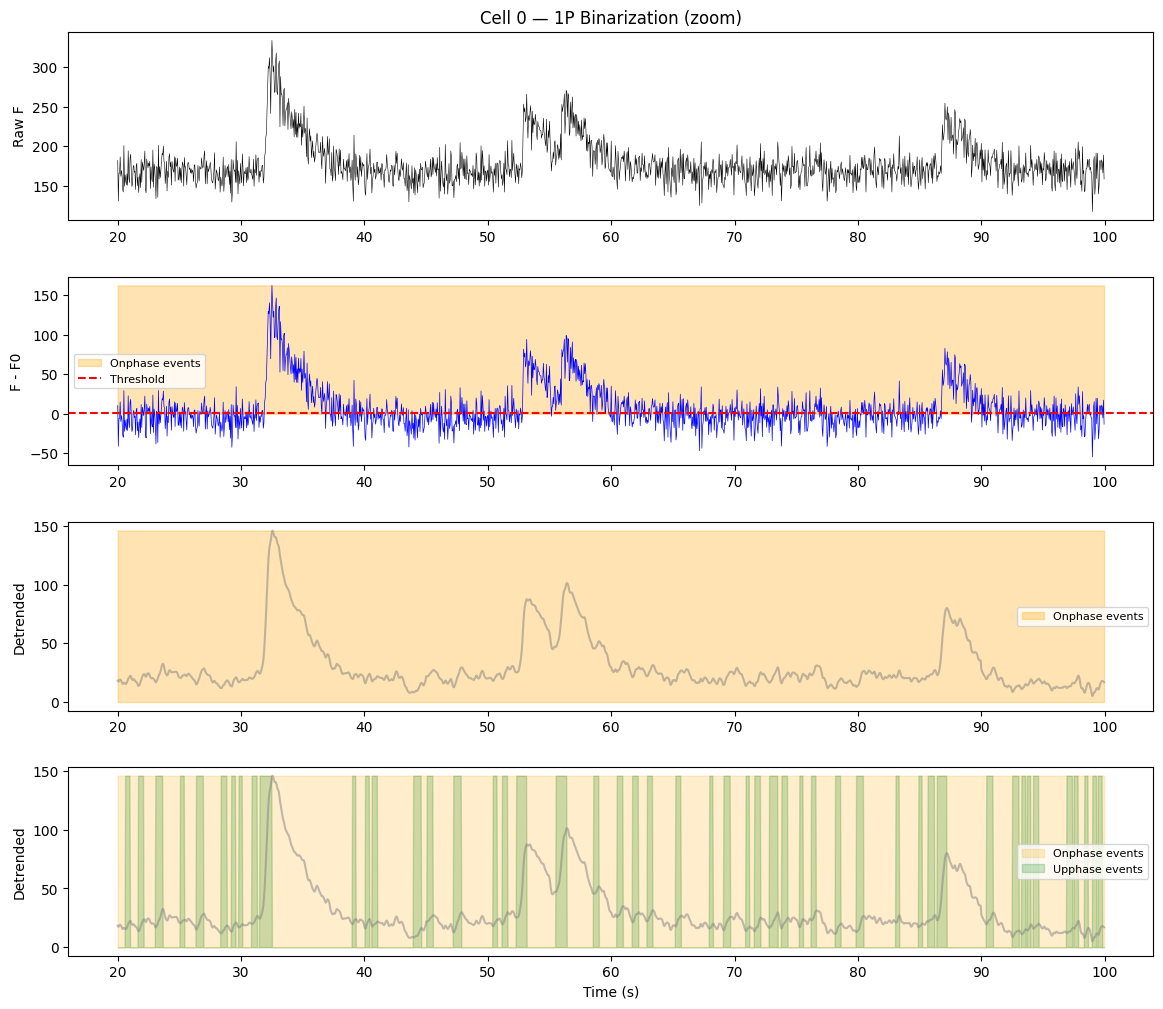

In [6]:
cell_id = 0
t = np.arange(result.F_raw.shape[1]) / cfg.sample_rate
zoom = slice(400, 2000)

fig = plt.figure(figsize=(14, 12))
gs = GridSpec(4, 1, figure=fig, hspace=0.3)

ax0 = fig.add_subplot(gs[0])
ax0.plot(t[zoom], result.F_raw[cell_id, zoom], 'k', linewidth=0.4)
ax0.set_ylabel('Raw F'); ax0.set_title(f'Cell {cell_id} — 1P Binarization (zoom)')

ax1 = fig.add_subplot(gs[1])
ax1.plot(t[zoom], result.dff[cell_id, zoom], 'b', linewidth=0.5)
ymax = result.dff[cell_id, zoom].max()
ax1.fill_between(t[zoom], 0, result.onphase[cell_id, zoom] * ymax,
                 alpha=0.3, color='orange', label='Onphase events')
ax1.axhline(y=result.thresholds[cell_id], color='r', linestyle='--', label='Threshold')
ax1.set_ylabel('F - F0'); ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[2])
ax2.plot(t[zoom], result.F_detrended[cell_id, zoom], 'gray', alpha=0.5)
ymax = result.F_detrended[cell_id, zoom].max()
ax2.fill_between(t[zoom], 0, result.onphase[cell_id, zoom] * ymax,
                 alpha=0.3, color='orange', label='Onphase events')
ax2.set_ylabel('Detrended'); ax2.legend(fontsize=8)

ax3 = fig.add_subplot(gs[3])
ax3.plot(t[zoom], result.F_detrended[cell_id, zoom], 'gray', alpha=0.5)
ymax = result.F_detrended[cell_id, zoom].max()
ax3.fill_between(t[zoom], 0, result.onphase[cell_id, zoom] * ymax,
                 alpha=0.2, color='orange', label='Onphase events')
ax3.fill_between(t[zoom], 0, result.upphase[cell_id, zoom] * ymax,
                 alpha=0.2, color='green', label='Upphase events')
ax3.set_ylabel('Detrended'); ax3.set_xlabel('Time (s)')
ax3.legend(fontsize=8)

plt.show()

## 5. Raster plot

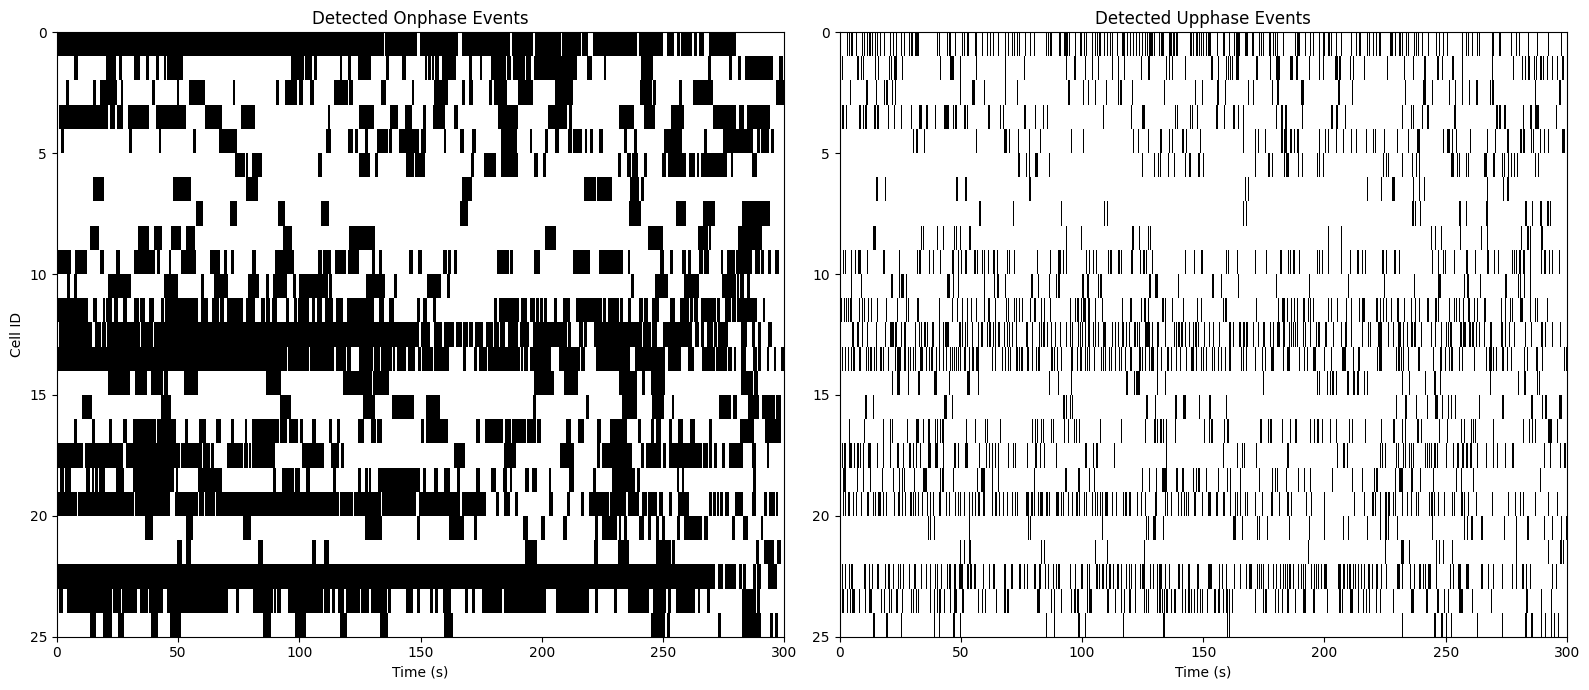

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.imshow(result.onphase, aspect='auto', cmap='Greys', interpolation='none',
          extent=[0, result.onphase.shape[1] / cfg.sample_rate, result.onphase.shape[0], 0])
ax.set_ylabel('Cell ID'); ax.set_xlabel('Time (s)')
ax.set_title('Detected Onphase Events')

ax = axes[1]
ax.imshow(result.upphase, aspect='auto', cmap='Greys', interpolation='none',
          extent=[0, result.upphase.shape[1] / cfg.sample_rate, result.upphase.shape[0], 0])
ax.set_xlabel('Time (s)')
ax.set_title('Detected Upphase Events')

plt.tight_layout(); plt.show()